## Лабораторная 5

1. Построить CNN для бинарной классификации изображений.
2. Загрузить [датасет](https://www.kaggle.com/datasets/sanikamal/horses-or-humans-dataset).
3. Выполнить аугментацию изображений.
4. Обучить модель на обученном датасете.
5. Получить метрику ROC-AUC.
6. Добиться значения ROC-AUC > 0.6.

*Дополнительное задание: 
Сделать интерфейс,, в который можно загружать изображение и получать информацию о том, человек находится на фото или лошадь*

In [13]:
import numpy as np
import pandas as pd
from tensorflow import keras
from matplotlib import pyplot as plt
import os
import cv2 as cv

In [ ]:
def open_imgs_in_folder(folder):
    arr = []
    for filename in os.listdir(folder):
        img = cv.imread(os.path.join(folder,filename))
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        img = np.array(img)
        if img is not None:
            arr.append(img)
    return arr

horse_imgs = open_imgs_in_folder("horse-or-human/train/horses")
human_imgs = open_imgs_in_folder("horse-or-human/train/humans")

x_train = [*horse_imgs, *human_imgs]
x_train = np.array(x_train)
y_train = np.vstack(( np.zeros((len(horse_imgs), 1)), 
                     np.ones((len(human_imgs), 1)) ))

horse_imgs_test = open_imgs_in_folder("horse-or-human/validation/horses")
human_imgs_test = open_imgs_in_folder("horse-or-human/validation/humans")

x_test = [*horse_imgs_test, *human_imgs_test]
x_test = np.array(x_test)
y_test = np.vstack(( np.zeros((len(horse_imgs_test), 1)), 
                     np.ones((len(human_imgs_test), 1)) ))

# 0 - для лошади
# 1 - для человека

In [ ]:
img_size = (300, 300)
num_of_channels = 3

In [ ]:
# This layer can be thought of as an all-in-one image augmentation layer. 
# The policy implemented by this layer has been benchmarked extensively 
# and is effective on a wide variety of datasets. (Из документации)
# Короче, все в одном.
augment_layer = keras.layers.RandAugment(
    value_range=(0, 255),
    num_ops=3,
    factor=0.25,
    seed=1234
)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Input((*img_size, num_of_channels, )),
    augment_layer,
    
    keras.layers.Conv2D(32, (5, 5), padding="same"),
    keras.layers.MaxPooling2D(pool_size=(3, 3)), # Shape на выходе - (32, 100, 100)
    keras.layers.Conv2D(64, (5, 5), padding="same"),
    keras.layers.MaxPooling2D(pool_size=(4, 4)), # Shape на выходе - (64, 25, 25)
    keras.layers.Conv2D(128, (5, 5), padding="same"),
    keras.layers.MaxPooling2D(pool_size=(5, 5)), # Shape на выходе - (128, 5, 5)

    keras.layers.Flatten(), # (3200)
    keras.layers.Dense(100, activation="sigmoid"),
    keras.layers.Dense(20, activation="sigmoid"),
    keras.layers.Dense(1, activation="sigmoid")
])

In [ ]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
                loss=keras.losses.BinaryCrossentropy,
                metrics=[keras.metrics.AUC(curve="ROC")])

In [ ]:
history = model.fit(x_train, y_train, epochs=100, batch_size=100, validation_data=(x_test, y_test))

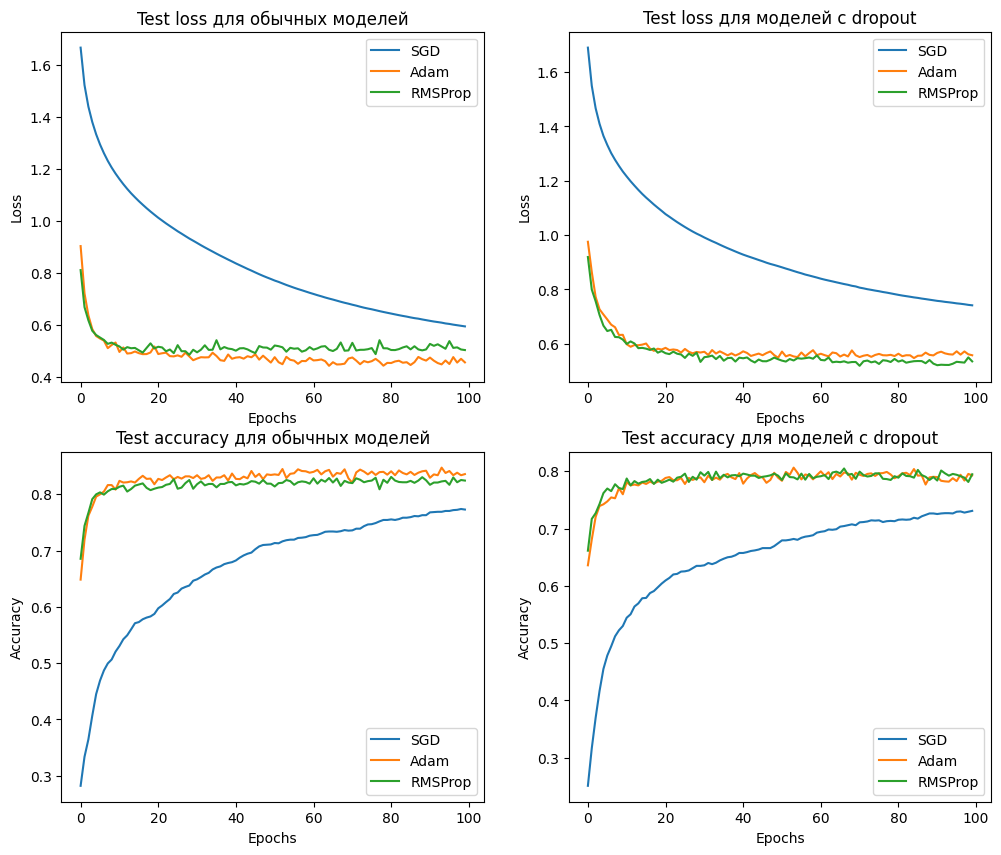

In [6]:
# Строим графики

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

for optim_name in optimizers.keys():
    ax1.plot(histories[optim_name].history[f"val_loss"], label=optim_name)
ax1.set_title('Test loss для обычных моделей')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

for optim_name in optimizers.keys():
    ax2.plot(histories[f"dropout_{optim_name}"].history[f"val_loss"], label=optim_name)
ax2.set_title('Test loss для моделей с dropout')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

for optim_name in optimizers.keys():
    ax3.plot(histories[optim_name].history[f"val_accuracy"], label=optim_name)
ax3.set_title('Test accuracy для обычных моделей')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Accuracy')
ax3.legend()

for optim_name in optimizers.keys():
    ax4.plot(histories[f"dropout_{optim_name}"].history[f"val_accuracy"], label=optim_name)
ax4.set_title('Test accuracy для моделей с dropout')
ax4.set_xlabel('Epochs')
ax4.set_ylabel('Accuracy')
ax4.legend()

plt.show()

### Вывод:
Простой оптимизатор SGD показывает наихудшие результаты. <br>
Более современные Adam и RMSProp показывают более быструю сходимость и более точные результаты: <br>
test accuracy оптимизаторов Adam и RMSProp превосходит test accuracy SGD на примерно 0.05. <br>
Между самими Adam и RMSProp особой разницы нет. <br>
Dropout в данном случае немного ухудшает результаты. <br>
Поскольку данные есть в достаточном кол-ве (N=10000) и не слишком зашумлены, <br>
то модель не переобучается и dropout оказывается бесполезен.